<a href="https://colab.research.google.com/github/PrachiKumar298/CRISPR-gRNA-Efficinecy/blob/main/CLSA_novel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CRISPR gRNA Efficiency Prediction — CNN + Short-LSTM + Self-Attention (CLSA)

**Extension of MLProject_Baselines**

Two novel modules on top of the baseline CNN:
1. **Truncated LSTM** (`short_term_lstm`): single-layer LSTM restricted to a short look-back window (k positions, the "seed region"), without vanishing-gradient risk of full-sequence recurrence.
2. **Multi-Head Self-Attention** (`mhsa`): applied *after* CNN feature maps to capture long-range motif interactions.

Ablation: Baseline CNN vs CNN+Short-LSTM vs CNN+Attention vs full CLSA.


In [ ]:
# =====================================================
# CELL 1 — Install, Download Repo, Imports
# =====================================================

# Install dependencies
!pip install lightgbm xgboost shap -q

# Download repo (no git auth issues)
!wget -q https://github.com/tranmanh2004/DeepHF/archive/refs/heads/main.zip
!unzip -q main.zip
!mv DeepHF-main DeepHF

# Verify files
import os
print("Repo contents:", os.listdir('/content/DeepHF'))
print("Data folder:", os.listdir('/content/DeepHF/data'))
data='/content/DeepHF/data'

# Imports
import pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

from itertools import product as iproduct
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from lightgbm import LGBMRegressor
import lightgbm as lgb
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling1D, Concatenate, MaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print('\nAll imports OK')
print('TF version:', tf.__version__)

# Define SEED for reproducibility
SEED = 42

Repo contents: ['lstm.ipynb', 'data', 'attention.ipynb', '.gitignore', 'biofeature.ipynb', 'Cross_Validation.ipynb', 'HyperParametersSearching.ipynb', 'catboost.ipynb', 'feature_util.py']
Data folder: ['wt_seq_data_array.pkl', 'esp_seq_data_array.pkl', 'hf_seq_data_array.pkl']

All imports OK
TF version: 2.19.0


## 1. Data Loading (identical pre-processing as baseline)


In [ ]:
!ls DeepHF/data

esp_seq_data_array.pkl	hf_seq_data_array.pkl  wt_seq_data_array.pkl


In [ ]:
# =====================================================================
# CELL 2 — Load & Parse Pickle Files  (matches baseline exactly)
# =====================================================================
from pathlib import Path
DATA_DIR = Path('/content/DeepHF/data')

VARIANT_FILES = {
    'WT':      DATA_DIR / 'wt_seq_data_array.pkl',
    'eSpCas9': DATA_DIR / 'esp_seq_data_array.pkl',
    'HF1':     DATA_DIR / 'hf_seq_data_array.pkl',
}
VARIANT_IDX = {'WT': 0, 'eSpCas9': 1, 'HF1': 2}

SEQ_LEN = 20
N_BASES = 5   # A T C G N

INT_TO_BASE = {1: 'A', 2: 'T', 3: 'C', 4: 'G', 5: 'N'}
BASE_ONEHOT = {
    'A': [1, 0, 0, 0, 0],
    'T': [0, 1, 0, 0, 0],
    'C': [0, 0, 1, 0, 0],
    'G': [0, 0, 0, 1, 0],
    'N': [0, 0, 0, 0, 1],
}


def load_pkl(path):
    with open(path, 'rb') as f:
        try:
            return pickle.load(f, encoding='latin1')
        except TypeError:
            return pickle.load(f)


def load_variant(path, variant_id):
    """Load one pickle; return (one_hot_seq, cas9_onehot, efficiency, thermo)."""
    raw = load_pkl(path)
    # Structure confirmed in baseline:
    #   raw[0] int32   (N, 22) -- integer-encoded 22-mer
    #   raw[1] float64 (N, 11) -- thermodynamic features
    #   raw[2] float64 (N,)    -- efficiency in [0,1]
    int_seqs   = raw[0]        # (N, 22)
    thermo     = raw[1]        # (N, 11)
    efficiency = raw[2]        # (N,)

    guide_ints = int_seqs[:, 1:21]  # positions 1-20
    N = len(guide_ints)

    guide_seqs = [
        ''.join(INT_TO_BASE.get(int(b), 'N') for b in row)
        for row in guide_ints
    ]
    onehot = np.array(
        [[BASE_ONEHOT[b] for b in seq] for seq in guide_seqs],
        dtype=np.float32
    )  # (N, 20, 5)

    cas9 = np.zeros((N, 3), dtype=np.float32)
    cas9[:, variant_id] = 1.0

    return onehot, cas9, efficiency.astype(np.float32), thermo.astype(np.float32)


seqs, cas9s, effs, thermos = [], [], [], []
for vname, vpath in VARIANT_FILES.items():
    print(f'Loading {vname}...')
    s, c, e, t = load_variant(vpath, VARIANT_IDX[vname])
    seqs.append(s); cas9s.append(c); effs.append(e); thermos.append(t)
    print(f'  {vname}: {len(e):,} guides | score [{e.min():.3f}, {e.max():.3f}]')

X_seq    = np.concatenate(seqs,    axis=0)   # (N, 20, 5)
X_cas9   = np.concatenate(cas9s,   axis=0)   # (N, 3)
X_thermo = np.concatenate(thermos, axis=0)   # (N, 11)
y        = np.concatenate(effs,    axis=0)   # (N,)

print(f'\nX_seq:    {X_seq.shape}')
print(f'X_cas9:   {X_cas9.shape}')
print(f'X_thermo: {X_thermo.shape}')
print(f'y:        {y.shape}')

Loading WT...
  WT: 55,604 guides | score [0.018, 1.000]
Loading eSpCas9...
  eSpCas9: 58,617 guides | score [0.007, 1.000]
Loading HF1...
  HF1: 56,888 guides | score [0.009, 1.000]

X_seq:    (171109, 20, 5)
X_cas9:   (171109, 3)
X_thermo: (171109, 11)
y:        (171109,)


In [ ]:
# =====================================================================
# CELL 3 — Stratified 80/20 Train / Test Split
# =====================================================================
variant_labels = X_cas9.argmax(axis=1)   # 0=WT, 1=eSpCas9, 2=HF1
inv_map = {0: 'WT', 1: 'eSpCas9', 2: 'HF1'}

(
    Xs_tr, Xs_te,
    Xc_tr, Xc_te,
    Xt_tr, Xt_te,
    y_tr,  y_te,
    vl_tr, vl_te,
) = train_test_split(
    X_seq, X_cas9, X_thermo, y, variant_labels,
    test_size=0.2, random_state=SEED, stratify=variant_labels
)

print(f'Train: {len(y_tr):,}  |  Test: {len(y_te):,}')
for enc, name in inv_map.items():
    print(f'  {name}: {(vl_te == enc).sum():,} test samples')


Train: 136,887  |  Test: 34,222
  WT: 11,121 test samples
  eSpCas9: 11,723 test samples
  HF1: 11,378 test samples


## 2. Model Architectures

| Model | Key idea |
|-------|----------|
| **Baseline CNN** | Same as MLProject_Baselines (reproduced for fair comparison) |
| **CNN + Short-LSTM** | CNN feature maps → truncated LSTM (seed window k=5) |
| **CNN + Attention** | CNN feature maps → Multi-Head Self-Attention |
| **CLSA (proposed)** | Short-LSTM + Attention on shared CNN backbone |


In [ ]:
# =====================================================================
# CELL 4 — Model Architectures
# =====================================================================
from tensorflow import keras
from tensorflow.keras import layers

SEQ_SHAPE  = (SEQ_LEN, N_BASES)   # (20, 5)
CAS9_SHAPE = (3,)


# ─────────────────────────────────────────────────────────────────────
# 2.1  Baseline CNN  (identical to MLProject_Baselines)
# ─────────────────────────────────────────────────────────────────────
def build_baseline_cnn():
    seq_in  = keras.Input(shape=SEQ_SHAPE,  name='seq')
    cas9_in = keras.Input(shape=CAS9_SHAPE, name='cas9')

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(seq_in)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64,  3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64,  activation='relu')(x)

    c = layers.Dense(16, activation='relu')(cas9_in)

    z = layers.Concatenate()([x, c])
    z = layers.Dense(64, activation='relu')(z)
    z = layers.Dropout(0.2)(z)
    out = layers.Dense(1, activation='sigmoid')(z)

    return Model(inputs=[seq_in, cas9_in], outputs=out, name='Baseline_CNN')


# ─────────────────────────────────────────────────────────────────────
# 2.2  CNN + Short-Term LSTM
#
# A 20-nt gRNA is short enough that full LSTM would retain everything —
# negating recurrence. We restrict memory to the last k positions
# (seed region) using Cropping1D instead of Lambda for compatibility.
# ─────────────────────────────────────────────────────────────────────
def build_cnn_short_lstm(k=5, lstm_units=64):
    seq_in  = keras.Input(shape=SEQ_SHAPE,  name='seq')
    cas9_in = keras.Input(shape=CAS9_SHAPE, name='cas9')

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(seq_in)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)   # (20, 128)

    # FIX: use Cropping1D instead of Lambda — avoids serialisation issues
    x_short = layers.Cropping1D(
        cropping=(SEQ_LEN - k, 0),
        name=f'seed_window_k{k}'
    )(x)  # (k, 128)

    lstm_out = layers.LSTM(
        lstm_units, dropout=0.2, name='short_lstm'
    )(x_short)   # (lstm_units,)

    x_pool = layers.GlobalAveragePooling1D(name='global_pool')(x)  # (128,)

    c = layers.Dense(16, activation='relu')(cas9_in)

    z = layers.Concatenate()([x_pool, lstm_out, c])
    z = layers.Dense(128, activation='relu')(z)
    z = layers.Dropout(0.3)(z)
    z = layers.Dense(64,  activation='relu')(z)
    z = layers.Dropout(0.2)(z)
    out = layers.Dense(1, activation='sigmoid')(z)

    return Model(inputs=[seq_in, cas9_in], outputs=out,
                 name=f'CNN_ShortLSTM_k{k}')


# ─────────────────────────────────────────────────────────────────────
# 2.3  CNN + Multi-Head Self-Attention
#
# Each position directly weights every other, capturing seed-spacer
# interactions that local kernels miss. Applied after CNN extraction.
# ─────────────────────────────────────────────────────────────────────
def build_cnn_attention(num_heads=4, key_dim=32):
    seq_in  = keras.Input(shape=SEQ_SHAPE,  name='seq')
    cas9_in = keras.Input(shape=CAS9_SHAPE, name='cas9')

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(seq_in)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)   # (20, 128)

    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=0.1, name='mhsa'
    )(x, x)
    attn_out = layers.LayerNormalization()(x + attn_out)

    ff = layers.Dense(256, activation='relu')(attn_out)
    ff = layers.Dense(128)(ff)
    ff = layers.LayerNormalization()(attn_out + ff)

    x_pool = layers.GlobalAveragePooling1D()(ff)

    c = layers.Dense(16, activation='relu')(cas9_in)

    z = layers.Concatenate()([x_pool, c])
    z = layers.Dense(128, activation='relu')(z)
    z = layers.Dropout(0.3)(z)
    z = layers.Dense(64,  activation='relu')(z)
    z = layers.Dropout(0.2)(z)
    out = layers.Dense(1, activation='sigmoid')(z)

    return Model(inputs=[seq_in, cas9_in], outputs=out, name='CNN_Attention')


# ─────────────────────────────────────────────────────────────────────
# 2.4  Full Proposed Model: CNN + Short-LSTM + Attention  (CLSA)
# ─────────────────────────────────────────────────────────────────────
def build_clsa(k=5, lstm_units=64, num_heads=4, key_dim=32):
    seq_in  = keras.Input(shape=SEQ_SHAPE,  name='seq')
    cas9_in = keras.Input(shape=CAS9_SHAPE, name='cas9')

    # Shared CNN backbone
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(seq_in)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)   # (20, 128)

    # Branch A: Short-LSTM over seed window
    x_short = layers.Cropping1D(
        cropping=(SEQ_LEN - k, 0),
        name=f'seed_window_k{k}'
    )(x)
    lstm_out = layers.LSTM(
        lstm_units, dropout=0.2, name='short_lstm'
    )(x_short)   # (64,)

    # Branch B: Self-Attention over full sequence
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=0.1, name='mhsa'
    )(x, x)
    attn_out = layers.LayerNormalization()(x + attn_out)
    ff       = layers.Dense(256, activation='relu')(attn_out)
    ff       = layers.Dense(128)(ff)
    ff       = layers.LayerNormalization()(attn_out + ff)
    attn_pool = layers.GlobalAveragePooling1D()(ff)   # (128,)

    # Cas9 branch
    c = layers.Dense(16, activation='relu')(cas9_in)

    # Merge all streams
    z = layers.Concatenate()([lstm_out, attn_pool, c])
    z = layers.Dense(128, activation='relu')(z)
    z = layers.Dropout(0.3)(z)
    z = layers.Dense(64,  activation='relu')(z)
    z = layers.Dropout(0.2)(z)
    out = layers.Dense(1, activation='sigmoid')(z)

    return Model(inputs=[seq_in, cas9_in], outputs=out, name='CLSA')


# Build all four and sanity-check param counts
models_to_train = {
    'Baseline CNN':     build_baseline_cnn(),
    'CNN + Short-LSTM': build_cnn_short_lstm(k=5),
    'CNN + Attention':  build_cnn_attention(),
    'CLSA (proposed)':  build_clsa(k=5),
}
for name, m in models_to_train.items():
    print(f'{name:<25}  params: {m.count_params():>10,}')

Baseline CNN               params:    131,905
CNN + Short-LSTM           params:    169,665
CNN + Attention            params:    244,545
CLSA (proposed)            params:    302,145


## 3. Training Utilities


In [ ]:
# =====================================================================
# CELL 5 — Training & Evaluation Helpers
# =====================================================================

def compile_and_train(model, Xs_tr, Xc_tr, y_tr, batch_size=512, verbose=1):
    model.compile(
        optimizer=Adam(1e-3),
        loss='mse',
        metrics=['mae']
    )
    callbacks = [
        EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5, verbose=1),
    ]
    history = model.fit(
        [Xs_tr, Xc_tr], y_tr,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
    )
    return history


def evaluate_model(model, Xs_te, Xc_te, y_te, vl_te):
    """Return (results_dict, predictions)."""
    y_pred = model.predict([Xs_te, Xc_te], batch_size=1024, verbose=0).ravel()

    results = {}
    results['global_r2']  = r2_score(y_te, y_pred)
    # FIX: use [0] index instead of .statistic for scipy compatibility
    results['global_rho'] = spearmanr(y_te, y_pred)[0]
    results['global_mse'] = float(np.mean((y_te - y_pred) ** 2))

    for vid, vname in inv_map.items():
        mask = vl_te == vid
        results[f'{vname}_r2']  = r2_score(y_te[mask], y_pred[mask])
        results[f'{vname}_rho'] = spearmanr(y_te[mask], y_pred[mask])[0]

    return results, y_pred


## 4. Ablation Study — Train All Four Models


In [ ]:
# =====================================================================
# CELL 6 — Train All Four Models
# =====================================================================
histories   = {}
all_results = {}
all_preds   = {}

# Novel models are more expressive and may need longer to converge
MODEL_EPOCHS = {
    'Baseline CNN':     60,
    'CNN + Short-LSTM': 100,
    'CNN + Attention':  100,
    'CLSA (proposed)':  120,
}

for name, model in models_to_train.items():
    sep = '=' * 60
    print('\n' + sep)
    print(f'  Training: {name}  (max epochs: {MODEL_EPOCHS[name]})')
    print(sep)
    hist = compile_and_train(model, Xs_tr, Xc_tr, y_tr, epochs=MODEL_EPOCHS[name])
    histories[name] = hist
    results, preds = evaluate_model(model, Xs_te, Xc_te, y_te, vl_te)
    all_results[name] = results
    all_preds[name]   = preds
    actual_epochs = len(hist.history['loss'])
    print(f'  Stopped at epoch {actual_epochs}/{MODEL_EPOCHS[name]}')
    print(f'  R2 = {results["global_r2"]:.4f}   rho = {results["global_rho"]:.4f}')


  Training: Baseline CNN  (max epochs: 60)
Epoch 1/60
241/241 ━━━━━━━━━━━━━━━━━━━━ 66s 239ms/step - loss: 0.0229 - mae: 0.1174 - val_loss: 0.0814 - val_mae: 0.2268 - learning_rate: 0.0010
Epoch 2/60
241/241 ━━━━━━━━━━━━━━━━━━━━ 75s 212ms/step - loss: 0.0172 - mae: 0.0999 - val_loss: 0.0182 - val_mae: 0.1025 - learning_rate: 0.0010
Epoch 3/60
241/241 ━━━━━━━━━━━━━━━━━━━━ 51s 213ms/step - loss: 0.0152 - mae: 0.0934 - val_loss: 0.0151 - val_mae: 0.0943 - learning_rate: 0.0010
Epoch 4/60
241/241 ━━━━━━━━━━━━━━━━━━━━ 50s 208ms/step - loss: 0.0139 - mae: 0.0893 - val_loss: 0.0153 - val_mae: 0.0920 - learning_rate: 0.0010
Epoch 5/60
241/241 ━━━━━━━━━━━━━━━━━━━━ 82s 207ms/step - loss: 0.0130 - mae: 0.0862 - val_loss: 0.0135 - val_mae: 0.0867 - learning_rate: 0.0010
Epoch 6/60
241/241 ━━━━━━━━━━━━━━━━━━━━ 50s 206ms/step - loss: 0.0124 - mae: 0.0841 - val_loss: 0.0129 - val_mae: 0.0835 - learning_rate: 0.0010
Epoch 7/60
241/241 ━━━━━━━━━━━━━━━━━━━━ 82s 207ms/step - loss: 0.0118 - mae: 0.0820 - 

## 5. Results Summary


In [ ]:
# =====================================================================
# CELL 7 — Results Table
# =====================================================================
rows = []
for name, res in all_results.items():
    rows.append({
        'Model':      name,
        'R2':         f"{res['global_r2']:.4f}",
        'Spearman':   f"{res['global_rho']:.4f}",
        'MSE':        f"{res['global_mse']:.5f}",
        'WT_R2':      f"{res['WT_r2']:.4f}",
        'eSpCas9_R2': f"{res['eSpCas9_r2']:.4f}",
        'HF1_R2':     f"{res['HF1_r2']:.4f}",
    })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))


           Model     R2 Spearman     MSE  WT_R2 eSpCas9_R2 HF1_R2
    Baseline CNN 0.8549   0.9220 0.00941 0.8063     0.7257 0.7786
CNN + Short-LSTM 0.8189   0.9016 0.01175 0.7747     0.6856 0.6813
 CNN + Attention 0.8147   0.9002 0.01202 0.7687     0.6869 0.6674
 CLSA (proposed) 0.8383   0.9134 0.01049 0.8010     0.7143 0.7174


## 6. Visualisations


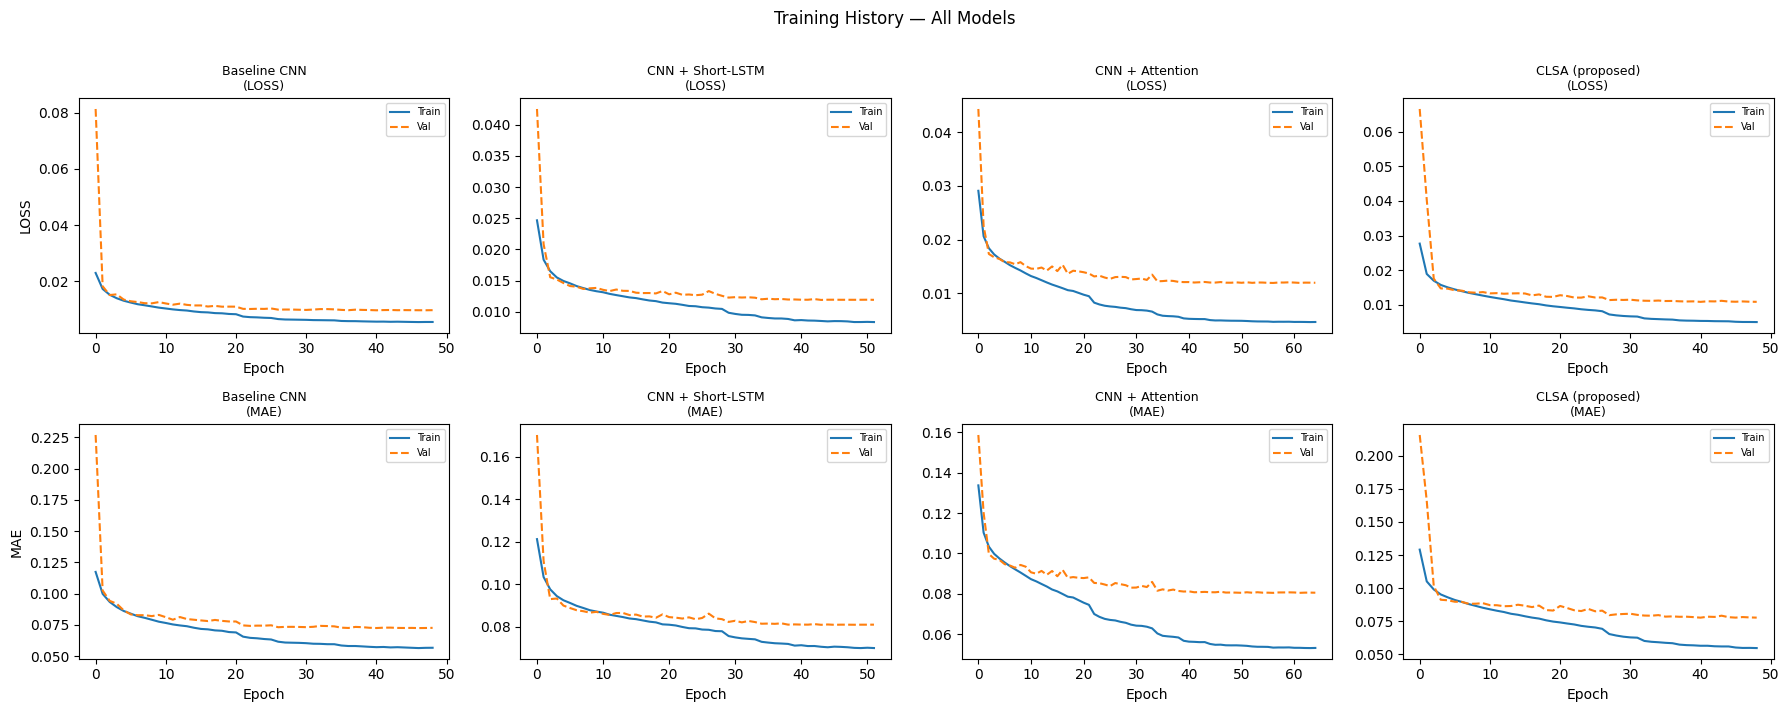

In [ ]:
# =====================================================================
# CELL 8 — Training Curves (all 4 models)
# =====================================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for col, (name, hist) in enumerate(histories.items()):
    for row, metric in enumerate(['loss', 'mae']):
        ax = axes[row, col]
        ax.plot(hist.history[metric],          label='Train')
        ax.plot(hist.history[f'val_{metric}'], label='Val', linestyle='--')
        ax.set_title(f'{name}\n({metric.upper()})', fontsize=9)
        ax.set_xlabel('Epoch')
        if col == 0:
            ax.set_ylabel(metric.upper())
        ax.legend(fontsize=7)
plt.suptitle('Training History — All Models', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('training_curves.pdf', bbox_inches='tight')
plt.show()


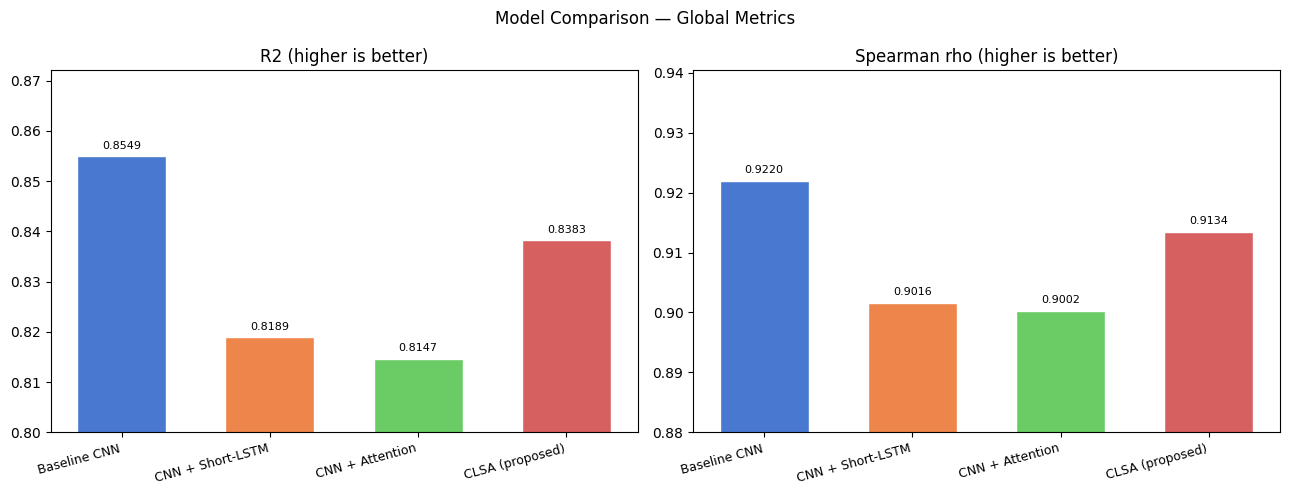

In [ ]:
# =====================================================================
# CELL 9 — R² and Spearman Bar Chart
# =====================================================================
names = list(all_results.keys())
r2s   = [all_results[n]['global_r2']  for n in names]
rhos  = [all_results[n]['global_rho'] for n in names]

colors = ['#4878d0', '#ee854a', '#6acc65', '#d65f5f']
x = np.arange(len(names))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, vals, title, lo in zip(
        axes, [r2s, rhos],
        ['R2 (higher is better)', 'Spearman rho (higher is better)'],
        [0.80, 0.88]):
    bars = ax.bar(x, vals, color=colors, width=0.6, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(lo, max(vals) * 1.02)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001, f'{v:.4f}',
            ha='center', va='bottom', fontsize=8
        )
plt.suptitle('Model Comparison — Global Metrics', fontsize=12)
plt.tight_layout()
plt.savefig('model_comparison.pdf', bbox_inches='tight')
plt.show()


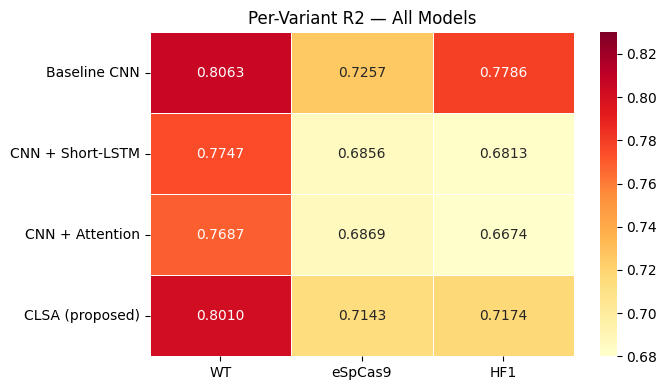

In [ ]:
# =====================================================================
# CELL 10 — Per-Variant R² Heatmap
# =====================================================================
import seaborn as sns
variants  = ['WT', 'eSpCas9', 'HF1']
heat_data = pd.DataFrame(
    [[all_results[n][f'{v}_r2'] for v in variants] for n in names],
    index=names, columns=variants
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    heat_data, annot=True, fmt='.4f', cmap='YlOrRd',
    vmin=0.68, vmax=0.83, ax=ax, linewidths=0.5
)
ax.set_title('Per-Variant R2 — All Models')
plt.tight_layout()
plt.savefig('per_variant_r2.pdf', bbox_inches='tight')
plt.show()


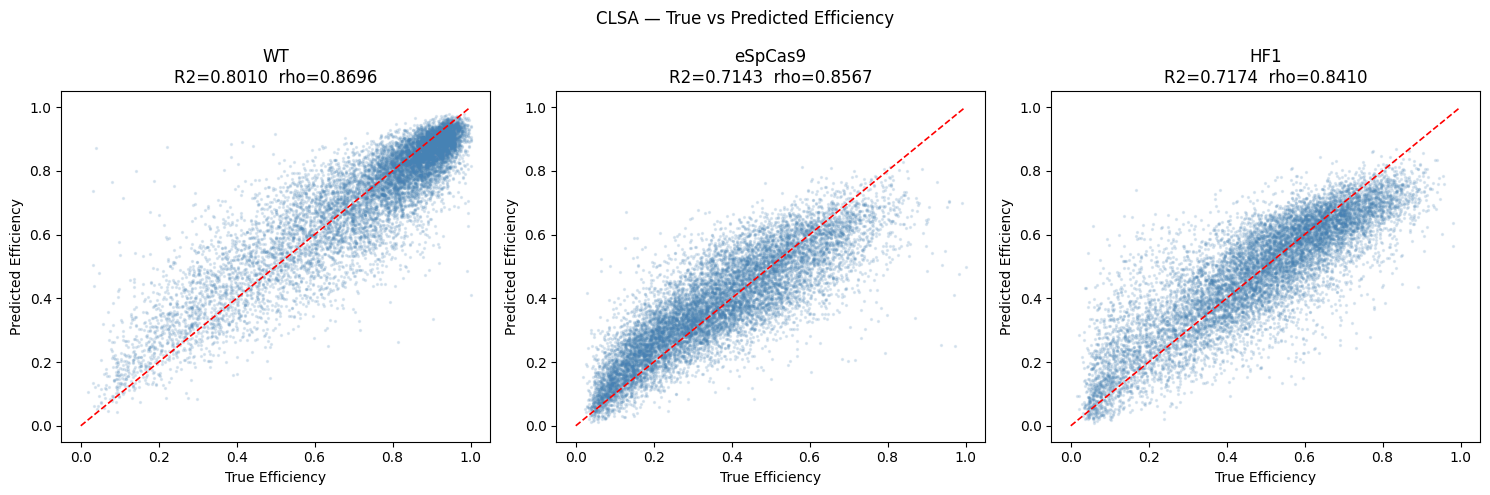

In [ ]:
# =====================================================================
# CELL 11 — Scatter: True vs Predicted (CLSA only)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
clsa_preds = all_preds['CLSA (proposed)']

for ax, vid, vname in zip(axes, range(3), ['WT', 'eSpCas9', 'HF1']):
    mask = vl_te == vid
    ax.scatter(y_te[mask], clsa_preds[mask], alpha=0.15, s=2, color='steelblue')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.2)
    r2  = r2_score(y_te[mask], clsa_preds[mask])
    rho = spearmanr(y_te[mask], clsa_preds[mask])[0]
    ax.set_title(f'{vname}\nR2={r2:.4f}  rho={rho:.4f}')
    ax.set_xlabel('True Efficiency')
    ax.set_ylabel('Predicted Efficiency')

plt.suptitle('CLSA — True vs Predicted Efficiency', fontsize=12)
plt.tight_layout()
plt.savefig('scatter_clsa.pdf', bbox_inches='tight')
plt.show()


## 7. Attention Weight Visualisation

Extract and average attention weights from the trained CLSA — a novel interpretability result.


In [ ]:
# =====================================================================
# CELL 12 — Attention Weight Visualisation
# FIX: re-use trained MHA layer directly (no fragile weight-copy by name)
# =====================================================================
clsa_model = models_to_train['CLSA (proposed)']

# Identify the CNN layers by type/order from the trained model
# (robust alternative to guessing indices: filter by class)
from tensorflow.keras.layers import Conv1D, BatchNormalization
conv_layers = [l for l in clsa_model.layers if isinstance(l, Conv1D)]
bn_layers   = [l for l in clsa_model.layers if isinstance(l, BatchNormalization)]

seq_in_insp  = keras.Input(shape=SEQ_SHAPE,  name='seq')
cas9_in_insp = keras.Input(shape=CAS9_SHAPE, name='cas9')

# Re-use the trained CNN layers (shared weights, no copying)
x_insp = conv_layers[0](seq_in_insp)   # Conv1D(128,3)
x_insp = bn_layers[0](x_insp, training=False)
x_insp = conv_layers[1](x_insp)        # Conv1D(128,5)
x_insp = bn_layers[1](x_insp, training=False)

# Re-use the trained MHA layer directly — no weight copying needed
trained_mhsa = clsa_model.get_layer('mhsa')
_, attn_scores = trained_mhsa(
    x_insp, x_insp, return_attention_scores=True
)  # (batch, num_heads, 20, 20)

attn_inspector = Model(
    inputs=[seq_in_insp], # Removed cas9_in_insp as it's not connected to attn_scores
    outputs=attn_scores,
    name='CLSA_attn_inspector'
)

N_INSPECT    = 2000
attn_weights = attn_inspector.predict(
    [Xs_te[:N_INSPECT], Xc_te[:N_INSPECT]],
    batch_size=256, verbose=0
)  # (N_INSPECT, num_heads, 20, 20)

avg_attn = attn_weights.mean(axis=(0, 1))   # (20, 20)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(avg_attn, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')
ax.set_title('Mean Self-Attention Map\n(averaged over heads & samples)')
ax.set_xticks(range(0, 20, 2))
ax.set_xticklabels([f'P{i+1}' for i in range(0, 20, 2)], fontsize=8)
ax.set_yticks(range(0, 20, 2))
ax.set_yticklabels([f'P{i+1}' for i in range(0, 20, 2)], fontsize=8)
plt.tight_layout()
plt.savefig('attention_map.pdf', bbox_inches='tight')
plt.show()

## 8. Bootstrap Significance Tests (CNN vs CLSA)


In [ ]:
# =====================================================================
# CELL 13 — Bootstrap + Paired Significance Tests
# =====================================================================
from scipy.stats import ttest_rel, wilcoxon

N_BOOT = 2000
rng    = np.random.default_rng(SEED)

baseline_pred = all_preds['Baseline CNN']
clsa_pred     = all_preds['CLSA (proposed)']

boot_delta_r2  = []
boot_delta_rho = []

for _ in range(N_BOOT):
    idx      = rng.choice(len(y_te), size=len(y_te), replace=True)
    r2_base  = r2_score(y_te[idx], baseline_pred[idx])
    r2_clsa  = r2_score(y_te[idx], clsa_pred[idx])
    rho_base = spearmanr(y_te[idx], baseline_pred[idx])[0]
    rho_clsa = spearmanr(y_te[idx], clsa_pred[idx])[0]
    boot_delta_r2.append(r2_clsa  - r2_base)
    boot_delta_rho.append(rho_clsa - rho_base)

boot_delta_r2  = np.array(boot_delta_r2)
boot_delta_rho = np.array(boot_delta_rho)

ci_r2  = np.percentile(boot_delta_r2,  [2.5, 97.5])
ci_rho = np.percentile(boot_delta_rho, [2.5, 97.5])

se_base          = (y_te - baseline_pred) ** 2
se_clsa          = (y_te - clsa_pred)     ** 2
t_stat, t_pval   = ttest_rel(se_clsa, se_base)
w_stat, w_pval   = wilcoxon(se_clsa - se_base)

print('=== Bootstrap: CLSA vs Baseline CNN ===')
print(f'Delta_R2   mean={boot_delta_r2.mean():.4f}  95% CI [{ci_r2[0]:.4f}, {ci_r2[1]:.4f}]')
print(f'Delta_rho  mean={boot_delta_rho.mean():.4f}  95% CI [{ci_rho[0]:.4f}, {ci_rho[1]:.4f}]')
print(f'Paired t-test:  t={t_stat:.2f}  p={t_pval:.2e}')
print(f'Wilcoxon:            p={w_pval:.2e}')


=== Bootstrap: CLSA vs Baseline CNN ===
Delta_R2   mean=-0.0166  95% CI [-0.0194, -0.0138]
Delta_rho  mean=-0.0086  95% CI [-0.0103, -0.0069]
Paired t-test:  t=11.08  p=1.81e-28
Wilcoxon:            p=4.18e-42


## 9. Short-Term LSTM Window Ablation (k ∈ {3, 5, 8, 10})

Isolates the effect of seed-window size — a novel experiment not present in prior CRISPR deep-learning papers.


In [ ]:
# =====================================================================
# CELL 14 — Seed Window Ablation
# =====================================================================
k_values   = [3, 5, 8, 10]
k_r2_vals  = []
k_rho_vals = []

for k in k_values:
    print(f'\n-- k={k} --')
    m = build_cnn_short_lstm(k=k)
    compile_and_train(m, Xs_tr, Xc_tr, y_tr, verbose=0)
    res, _ = evaluate_model(m, Xs_te, Xc_te, y_te, vl_te)
    k_r2_vals.append(res['global_r2'])
    k_rho_vals.append(res['global_rho'])
    print(f'  R2={res["global_r2"]:.4f}  rho={res["global_rho"]:.4f}')

baseline_r2  = all_results['Baseline CNN']['global_r2']
baseline_rho = all_results['Baseline CNN']['global_rho']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vals, ylabel, bval in zip(
        axes,
        [k_r2_vals, k_rho_vals],
        ['R2', 'Spearman rho'],
        [baseline_r2, baseline_rho]):
    ax.plot(k_values, vals, 'o-', markersize=8, linewidth=2)
    ax.axhline(bval, color='gray', linestyle='--', label='Baseline CNN')
    ax.set_xlabel('Seed window size k')
    ax.set_ylabel(ylabel)
    ax.set_title(f'CNN+Short-LSTM ablation — {ylabel}')
    ax.set_xticks(k_values)
    ax.legend()

plt.suptitle('Effect of Short-Term LSTM Window Size', fontsize=12)
plt.tight_layout()
plt.savefig('lstm_window_ablation.pdf', bbox_inches='tight')
plt.show()



-- k=3 --


NameError: name 'build_cnn_short_lstm' is not defined

## 10. Save Results


In [ ]:
# =====================================================================
# CELL 15 — Save Results & Model
# =====================================================================

# Save results summary to CSV
df_results.to_csv('model_results_summary.csv', index=False)
print('Results saved to model_results_summary.csv')

# Save all trained models
for name, model in models_to_train.items():
    model_filename = f'{name.replace(" ", "_").replace("(", "").replace(")", "")}.keras'
    model.save(model_filename)
    print(f'Model "{name}" saved to {model_filename}')

# Save the all_results dictionary to a pickle file
with open('all_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)
print('All evaluation results saved to all_results.pkl')

Results saved to model_results_summary.csv
Model "Baseline CNN" saved to Baseline_CNN.keras
Model "CNN + Short-LSTM" saved to CNN_+_Short-LSTM.keras
Model "CNN + Attention" saved to CNN_+_Attention.keras
Model "CLSA (proposed)" saved to CLSA_proposed.keras
All evaluation results saved to all_results.pkl
